pedestal peak QDC: t0=31.1237 ns, t_end=62.5339 ns, integral=4.25305 mV ns
pedestal noise QDC: t0=30.8655 ns, t_end=41.394 ns, integral=0.404142 mV ns
pedestal-like 0-80 ns QDC: t0=0 ns, t_end=80 ns, integral=0.691893 mV ns


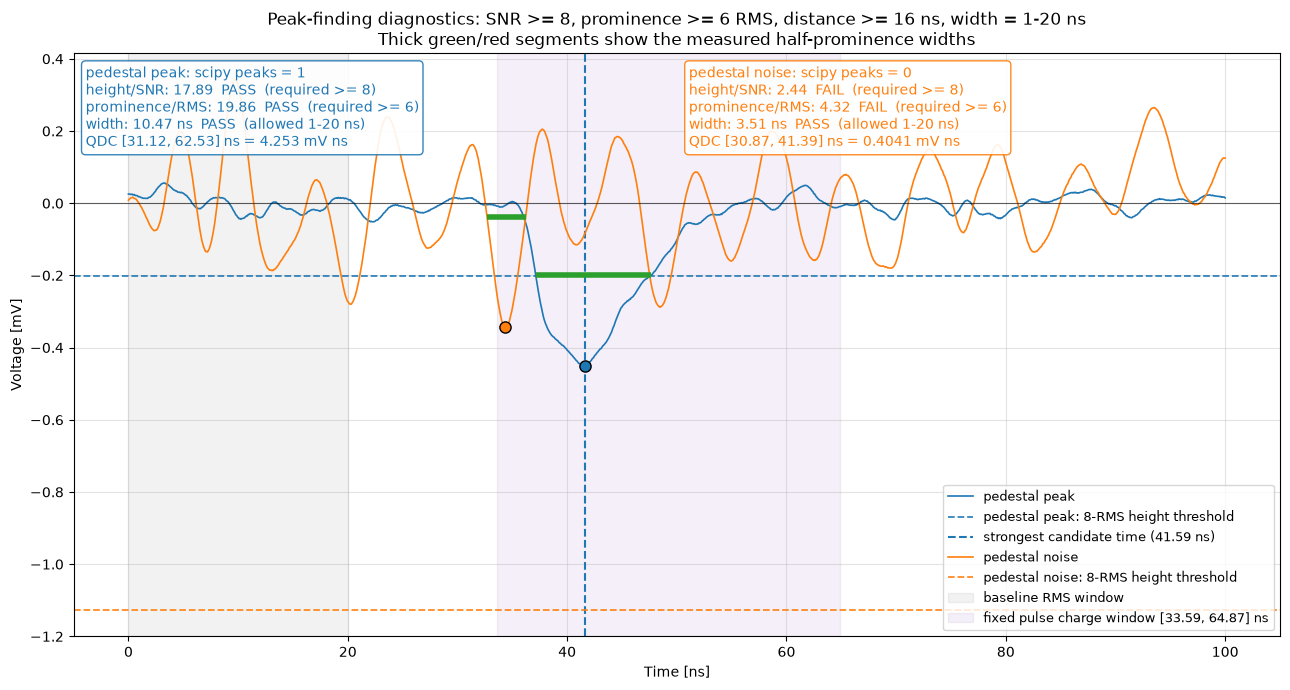

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences, peak_widths

ped_peak = np.load("time_and_example_wf_pedestal_peak.npy", allow_pickle=True)
ped_noise = np.load("time_and_example_wf_pedestal_noise.npy", allow_pickle=True)

baseline_window_ns = (0.0, 20.0)
peak_snr_threshold = 8.0
peak_prominence_snr = 6.0
peak_distance_samples = 1024
peak_width_samples = (64, None)
# Learned window loaded by the current standalone Fit.ipynb cache.
fixed_pulse_window_charge = {
    "window_ns": (33.58943045538215, 64.87164332585925),
}

def measure_strongest_candidate(saved_waveform):
    time_ns = np.asarray(saved_waveform[0][0], dtype=float)
    voltage_mV = np.asarray(saved_waveform[0][1], dtype=float)
    baseline_mask = (time_ns >= baseline_window_ns[0]) & (time_ns <= baseline_window_ns[1])
    baseline_mean_mV = float(np.mean(voltage_mV[baseline_mask]))
    baseline_rms_mV = float(np.std(voltage_mV[baseline_mask]))
    pulse_positive_mV = -(voltage_mV - baseline_mean_mV)
    candidates, _ = find_peaks(pulse_positive_mV)
    candidate_idx = int(candidates[np.argmax(pulse_positive_mV[candidates])])
    amplitude_mV = float(pulse_positive_mV[candidate_idx])
    prominence_mV = float(peak_prominences(pulse_positive_mV, [candidate_idx])[0][0])
    widths, width_heights, left_ips, right_ips = peak_widths(
        pulse_positive_mV, [candidate_idx], rel_height=0.5
    )
    dt_ns = float(np.mean(np.diff(time_ns)))
    width_ns = float(widths[0] * dt_ns)
    peak_time_ns = float(time_ns[candidate_idx])
    qdc_t0_ns = peak_time_ns - width_ns
    qdc_t_end_ns = peak_time_ns + 2.0 * width_ns
    if qdc_t0_ns < time_ns[0] or qdc_t_end_ns > time_ns[-1]:
        raise ValueError("Requested QDC window extends outside the waveform")
    qdc_inner_mask = (time_ns > qdc_t0_ns) & (time_ns < qdc_t_end_ns)
    qdc_time_ns = np.concatenate(([qdc_t0_ns], time_ns[qdc_inner_mask], [qdc_t_end_ns]))
    qdc_voltage_mV = np.interp(qdc_time_ns, time_ns, pulse_positive_mV)
    qdc_mV_ns = float(np.trapezoid(qdc_voltage_mV, qdc_time_ns))
    pedestal_qdc_t0_ns = 0.0
    pedestal_qdc_t_end_ns = 80.0
    pedestal_inner_mask = (time_ns > pedestal_qdc_t0_ns) & (time_ns < pedestal_qdc_t_end_ns)
    pedestal_qdc_time_ns = np.concatenate((
        [pedestal_qdc_t0_ns], time_ns[pedestal_inner_mask], [pedestal_qdc_t_end_ns]
    ))
    pedestal_qdc_voltage_mV = np.interp(
        pedestal_qdc_time_ns, time_ns, pulse_positive_mV
    )
    pedestal_qdc_mV_ns = float(np.trapezoid(
        pedestal_qdc_voltage_mV, pedestal_qdc_time_ns
    ))
    qualifying_peaks, _ = find_peaks(
        pulse_positive_mV,
        height=peak_snr_threshold * baseline_rms_mV,
        prominence=peak_prominence_snr * baseline_rms_mV,
        distance=peak_distance_samples,
        width=peak_width_samples,
    )
    return {
        "time_ns": time_ns,
        "voltage_mV": voltage_mV,
        "baseline_mean_mV": baseline_mean_mV,
        "baseline_rms_mV": baseline_rms_mV,
        "candidate_idx": candidate_idx,
        "amplitude_mV": amplitude_mV,
        "snr": amplitude_mV / baseline_rms_mV,
        "prominence_mV": prominence_mV,
        "prominence_snr": prominence_mV / baseline_rms_mV,
        "width_samples": float(widths[0]),
        "width_ns": width_ns,
        "width_level_mV": float(baseline_mean_mV - width_heights[0]),
        "width_left_ns": float(np.interp(left_ips[0], np.arange(len(time_ns)), time_ns)),
        "width_right_ns": float(np.interp(right_ips[0], np.arange(len(time_ns)), time_ns)),
        "height_threshold_mV": peak_snr_threshold * baseline_rms_mV,
        "prominence_threshold_mV": peak_prominence_snr * baseline_rms_mV,
        "qdc_t0_ns": qdc_t0_ns,
        "qdc_t_end_ns": qdc_t_end_ns,
        "qdc_mV_ns": qdc_mV_ns,
        "pedestal_qdc_t0_ns": pedestal_qdc_t0_ns,
        "pedestal_qdc_t_end_ns": pedestal_qdc_t_end_ns,
        "pedestal_qdc_mV_ns": pedestal_qdc_mV_ns,
        "n_qualifying_peaks": len(qualifying_peaks),
    }

waveform_specs = [
    ("pedestal peak", ped_peak, "tab:blue", 0.01),
    ("pedestal noise", ped_noise, "tab:orange", 0.51),
]
fig, ax = plt.subplots(figsize=(13, 7))
for label, saved_waveform, color, text_x in waveform_specs:
    result = measure_strongest_candidate(saved_waveform)
    time_ns = result["time_ns"]
    voltage_mV = result["voltage_mV"]
    candidate_idx = result["candidate_idx"]
    passes_height = result["snr"] >= peak_snr_threshold
    passes_prominence = result["prominence_snr"] >= peak_prominence_snr
    passes_width = result["width_samples"] >= peak_width_samples[0]

    ax.plot(time_ns, voltage_mV, label=label, color=color, linewidth=1.2)
    ax.axhline(
        result["baseline_mean_mV"] - result["height_threshold_mV"],
        color=color, linestyle="--", linewidth=1.3, alpha=0.9,
        label=f"{label}: 8-RMS height threshold",
    )
    ax.scatter(
        time_ns[candidate_idx], voltage_mV[candidate_idx],
        color=color, edgecolor="black", s=65, zorder=5,
    )
    width_color = "tab:green" if passes_width else "tab:red"
    ax.hlines(
        result["width_level_mV"],
        result["width_left_ns"], result["width_right_ns"],
        color=width_color, linewidth=4, zorder=4,
    )
    status = (
        f"{label}: scipy peaks = {result['n_qualifying_peaks']}\n"
        f"height/SNR: {result['snr']:.2f}  {'PASS' if passes_height else 'FAIL'}  (required >= {peak_snr_threshold:g})\n"
        f"prominence/RMS: {result['prominence_snr']:.2f}  {'PASS' if passes_prominence else 'FAIL'}  (required >= {peak_prominence_snr:g})\n"
        f"width: {result['width_ns']:.2f} ns  {'PASS' if passes_width else 'FAIL'}  (allowed 1-20 ns)\n"
        f"QDC [{result['qdc_t0_ns']:.2f}, {result['qdc_t_end_ns']:.2f}] ns = {result['qdc_mV_ns']:.4g} mV ns"
    )
    print(
        f"{label} QDC: t0={result['qdc_t0_ns']:.6g} ns, "
        f"t_end={result['qdc_t_end_ns']:.6g} ns, "
        f"integral={result['qdc_mV_ns']:.6g} mV ns"
    )
    if label == "pedestal noise":
        print(
            f"pedestal-like 0-80 ns QDC: t0={result['pedestal_qdc_t0_ns']:.6g} ns, "
            f"t_end={result['pedestal_qdc_t_end_ns']:.6g} ns, "
            f"integral={result['pedestal_qdc_mV_ns']:.6g} mV ns"
        )
    ax.text(
        text_x, 0.98, status, transform=ax.transAxes, va="top", ha="left",
        color=color, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=color, alpha=0.9),
    )
    if label == "pedestal peak":
        ax.axvline(
            time_ns[candidate_idx], color=color, linestyle="--", linewidth=1.5,
            label=f"strongest candidate time ({time_ns[candidate_idx]:.2f} ns)",
        )

ax.axvspan(*baseline_window_ns, color="0.5", alpha=0.10, label="baseline RMS window")
ax.axvspan(
    *fixed_pulse_window_charge["window_ns"], color="tab:purple", alpha=0.10,
    label=(
        f"fixed pulse charge window "
        f"[{fixed_pulse_window_charge['window_ns'][0]:.2f}, "
        f"{fixed_pulse_window_charge['window_ns'][1]:.2f}] ns"
    ),
)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
ax.set(
    xlabel="Time [ns]", ylabel="Voltage [mV]",
    title=(
        "Peak-finding diagnostics: SNR >= 8, prominence >= 6 RMS, "
        "distance >= 16 ns, width = 1-20 ns\n"
        "Thick green/red segments show the measured half-prominence widths"
    ),
)
ax.grid(True, which="both", alpha=0.35)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

In [44]:
from scipy.signal import find_peaks, peak_prominences, peak_widths

# Match the current Batch_analysis.ipynb peak-detection settings.
baseline_window_ns = (0.0, 20.0)
peak_snr_threshold = 8.0
peak_prominence_snr = 6.0
peak_distance_samples = 1024
peak_width_samples = (64, None)

def print_peak_diagnostics(label, saved_waveform):
    time_ns = np.asarray(saved_waveform[0][0], dtype=float)
    voltage_mV = np.asarray(saved_waveform[0][1], dtype=float)
    baseline_mask = (time_ns >= baseline_window_ns[0]) & (time_ns <= baseline_window_ns[1])
    if not np.any(baseline_mask):
        raise ValueError(f"{label}: baseline window contains no samples")

    baseline_mean_mV = float(np.mean(voltage_mV[baseline_mask]))
    baseline_rms_mV = float(np.std(voltage_mV[baseline_mask]))
    baseline_subtracted_mV = voltage_mV - baseline_mean_mV
    # PMT pulses are negative, while scipy.find_peaks searches upward.
    pulse_positive_mV = -baseline_subtracted_mV
    dt_ns = float(np.mean(np.diff(time_ns)))
    height_threshold_mV = peak_snr_threshold * baseline_rms_mV
    prominence_threshold_mV = peak_prominence_snr * baseline_rms_mV

    # Measure the strongest local maximum even if a configured cut rejects it.
    candidate_indices, _ = find_peaks(pulse_positive_mV)
    print(f"\n{label}")
    print("-" * len(label))
    print(f"baseline mean              = {baseline_mean_mV:.6g} mV")
    print(f"baseline RMS               = {baseline_rms_mV:.6g} mV")
    print(f"find_peaks height threshold = {height_threshold_mV:.6g} mV ({peak_snr_threshold:g} sigma)")
    print(f"prominence threshold        = {prominence_threshold_mV:.6g} mV ({peak_prominence_snr:g} sigma)")
    print(f"distance requirement        = {peak_distance_samples} samples ({peak_distance_samples * dt_ns:.6g} ns)")
    print(f"accepted width range        = >= {peak_width_samples[0]} samples ({peak_width_samples[0] * dt_ns:.6g} ns); no upper limit")

    if len(candidate_indices) == 0:
        print("No local maximum was found.")
        return

    candidate_idx = int(candidate_indices[np.argmax(pulse_positive_mV[candidate_indices])])
    amplitude_mV = float(pulse_positive_mV[candidate_idx])
    snr = amplitude_mV / baseline_rms_mV if baseline_rms_mV > 0 else np.inf
    prominence_mV = float(peak_prominences(pulse_positive_mV, [candidate_idx])[0][0])
    prominence_snr = prominence_mV / baseline_rms_mV if baseline_rms_mV > 0 else np.inf
    width_samples = float(peak_widths(pulse_positive_mV, [candidate_idx], rel_height=0.5)[0][0])
    width_ns = width_samples * dt_ns
    peak_time_ns = float(time_ns[candidate_idx])
    qdc_t0_ns = peak_time_ns - width_ns
    qdc_t_end_ns = peak_time_ns + 2.0 * width_ns
    qdc_inner_mask = (time_ns > qdc_t0_ns) & (time_ns < qdc_t_end_ns)
    qdc_time_ns = np.concatenate(([qdc_t0_ns], time_ns[qdc_inner_mask], [qdc_t_end_ns]))
    qdc_voltage_mV = np.interp(qdc_time_ns, time_ns, pulse_positive_mV)
    qdc_mV_ns = float(np.trapezoid(qdc_voltage_mV, qdc_time_ns))

    passes_height = amplitude_mV >= height_threshold_mV
    passes_prominence = prominence_mV >= prominence_threshold_mV
    passes_width = width_samples >= peak_width_samples[0]
    print(f"strongest candidate time    = {time_ns[candidate_idx]:.6g} ns (sample {candidate_idx})")
    print(f"peak amplitude              = {amplitude_mV:.6g} mV")
    print(f"peak SNR                    = {snr:.6g}")
    print(f"peak prominence             = {prominence_mV:.6g} mV")
    print(f"prominence / baseline RMS   = {prominence_snr:.6g}")
    print(f"peak width at half prominence = {width_samples:.6g} samples = {width_ns:.6g} ns")
    print(f"QDC window                  = [{qdc_t0_ns:.6g}, {qdc_t_end_ns:.6g}] ns")
    print(f"QDC integral                = {qdc_mV_ns:.6g} mV ns")
    print(f"passes height condition     = {passes_height}")
    print(f"passes prominence condition = {passes_prominence}")
    print(f"passes width condition      = {passes_width}")

    qualifying_peaks, properties = find_peaks(
        pulse_positive_mV,
        height=height_threshold_mV,
        prominence=prominence_threshold_mV,
        distance=peak_distance_samples,
        width=peak_width_samples,
    )
    print(f"qualifying peaks returned by scipy.find_peaks = {len(qualifying_peaks)}")
    if len(qualifying_peaks):
        for number, peak_idx in enumerate(qualifying_peaks, start=1):
            property_idx = number - 1
            print(
                f"  peak {number}: t={time_ns[peak_idx]:.6g} ns, "
                f"amplitude={properties['peak_heights'][property_idx]:.6g} mV, "
                f"SNR={properties['peak_heights'][property_idx] / baseline_rms_mV:.6g}, "
                f"width={properties['widths'][property_idx]:.6g} samples "
                f"({properties['widths'][property_idx] * dt_ns:.6g} ns)"
            )

print_peak_diagnostics("pedestal peak", ped_peak)
print_peak_diagnostics("pedestal noise", ped_noise)



pedestal peak
-------------
baseline mean              = 1.38778e-18 mV
baseline RMS               = 0.0251466 mV
find_peaks height threshold = 0.201173 mV (8 sigma)
prominence threshold        = 0.150879 mV (6 sigma)
distance requirement        = 1024 samples (16 ns)
accepted width range        = >= 64 samples (1 ns); no upper limit
strongest candidate time    = 41.5938 ns (sample 2662)
peak amplitude              = 0.449965 mV
peak SNR                    = 17.8937
peak prominence             = 0.49949 mV
prominence / baseline RMS   = 19.8631
peak width at half prominence = 670.083 samples = 10.4701 ns
QDC window                  = [31.1237, 62.5339] ns
QDC integral                = 4.25305 mV ns
passes height condition     = True
passes prominence condition = True
passes width condition      = True
qualifying peaks returned by scipy.find_peaks = 1
  peak 1: t=41.5938 ns, amplitude=0.449965 mV, SNR=17.8937, width=670.083 samples (10.4701 ns)

pedestal noise
--------------
baseline me